### Agent-Lab: Vision Document Agent

Objective of this notebook is evaluating and adapting the implementation of [Multi-modal Agent](https://python.langchain.com/docs/integrations/llms/ollama/#multi-modal) specialized on documents.

---

In [1]:
%%capture
import json
import os
import nest_asyncio
from IPython.display import Image, Markdown, display
from dotenv import load_dotenv
from notebooks import experiment_utils
from agent_lab.interface.api.messages.schema import MessageRequest

os.chdir("..")
load_dotenv()
nest_asyncio.apply()

# start dependency injection container
container = experiment_utils.bootstrap_container([__name__])

# get checkpointer instance
graph_persistence_factory = container.graph_persistence_factory()
checkpointer = graph_persistence_factory.build_checkpoint_saver()

---
### Upload Document:


**Image:**

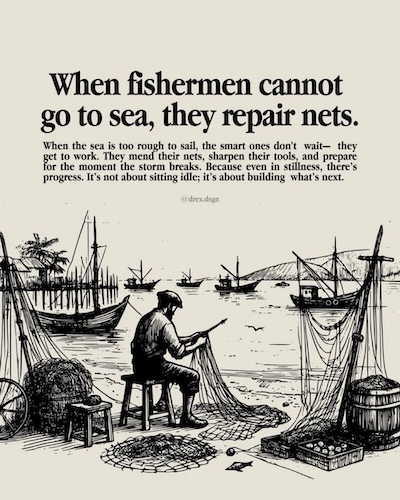

In [2]:
# create attachment
attachment_id = experiment_utils.create_attachment(
    file_path="tests/integration/vision_document_01.jpg", content_type="image/jpeg"
)
display(Markdown("**Image:**"))
display(Image(filename="tests/integration/vision_document_01.jpg"))

---
### XAI Grok Vision Document Agent

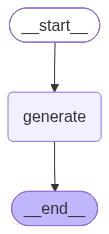

In [3]:
# Create Workflow
xai_agent = experiment_utils.create_xai_agent(
    agent_type="vision_document", llm_tag="grok-4-latest", api_key=os.getenv("XAI_API_KEY")
)
xai_vision_document_agent = container.agent_registry().get_agent("vision_document")
xai_workflow_builder = xai_vision_document_agent.get_workflow_builder(xai_agent["id"])
xai_workflow = xai_workflow_builder.compile(checkpointer=checkpointer)

experiment_utils.print_graph(xai_workflow)

In [4]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="You are studying this material, please generate a comprehensive overview, explain with details. Make sure your analysis does not overlook details.",
    agent_id=xai_agent["id"],
    attachment_id=attachment_id,
)

inputs = xai_vision_document_agent.get_input_params(message, schema="public")
config = xai_vision_document_agent.get_config(xai_agent["id"])
result = xai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = xai_vision_document_agent.format_response(result)

In [5]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

**Main Topic/Purpose**  
This page presents a motivational parable/quote illustrated with a classic black-and-white line drawing. Its core message is that productive people use periods of forced inactivity (bad weather, setbacks, “storms”) to prepare and improve, so they are ready when opportunity returns. The image and text work together as a visual metaphor for resilience, foresight, and continuous progress.

**Full Text Transcription**  
- Headline (large, bold):  
  “When fishermen cannot go to sea, they repair nets.”

- Body paragraph:  
  “When the sea is too rough to sail, the smart ones don’t wait— they get to work. They mend their nets, sharpen their tools, and prepare for the moment the storm breaks. Because even in stillness, there’s progress. It’s not about sitting idle; it’s about building what’s next.”

- Attribution (small, centered):  
  “@drex.dsgn”

**Detailed Description of the Illustration**  
The drawing depicts a serene yet purposeful harbor scene rendered in fine ink lines on an off-white background. In the foreground, a seated fisherman wearing a cap and work clothes sits on a low wooden stool, intently repairing a large, spread-out fishing net. The net is draped over a barrel and extends across the ground; he holds a section of it in his hands, needle or twine visible.  

To his left are traditional fishing tools: a large wooden ship’s wheel leaning against a barrel, a small three-legged stool, and a coiled rope or net bundle. To his right stands a tall wooden drying rack with another net hanging from it.  

In the mid-ground and background, several wooden fishing boats are visible—some beached on the shore, others floating calmly on the water. Two or three gulls fly low over the water. The distant shoreline shows low hills, a few trees, and additional boats at anchor. The overall composition is balanced, peaceful, and timeless, evoking a classic coastal fishing village.

**Interpretation and Key Insights**  
- **Metaphor at work**: The fisherman’s deliberate mending of nets during calm (or stormy) weather symbolizes using downtime for maintenance and skill-building. The text explicitly states that “even in stillness, there’s progress,” turning idleness into preparation.  
- **Contrast between image and text**: The illustration shows a tranquil harbor with boats at rest, yet the caption frames this as the moment when “the sea is too rough.” This visual-textual tension reinforces the idea that external conditions may look peaceful while real work is happening behind the scenes.  
- **Broader life/business lesson**: The page distills a universal principle—successful individuals or teams treat forced pauses (market downturns, project delays, personal setbacks) as opportunities to sharpen tools, refine processes, and build capacity for the next surge of activity.  
- **Tone and style**: The language is direct, proverbial, and slightly poetic (“the storm breaks,” “building what’s next”). The illustration’s vintage engraving style lends gravitas and universality, making the message feel timeless rather than tied to any specific era or industry.

**RAG-Suitable Summary for Knowledge Base**  
This slide is a self-contained motivational micro-lesson: when external conditions prevent forward motion, wise practitioners invest in maintenance and preparation. The combination of concise proverbial headline, explanatory paragraph, and evocative coastal illustration creates a memorable, transferable analogy applicable to entrepreneurship, personal development, project management, or any domain where resilience and proactive use of downtime determine long-term success.

---
### OpenAI Vision Document Agent

In [6]:
# Create Workflow
openai_agent = experiment_utils.create_openai_agent(
    agent_type="vision_document", llm_tag="gpt-5-nano", api_key=os.getenv("OPENAI_API_KEY")
)
openai_vision_document_agent = container.agent_registry().get_agent("vision_document")
openai_workflow_builder = openai_vision_document_agent.get_workflow_builder(openai_agent["id"])
openai_workflow = openai_workflow_builder.compile(checkpointer=checkpointer)

In [7]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="You are studying this material, please generate a comprehensive overview, explain with details. Make sure your analysis does not overlook details.",
    agent_id=openai_agent["id"],
    attachment_id=attachment_id,
)

inputs = openai_vision_document_agent.get_input_params(message, schema="public")
config = openai_vision_document_agent.get_config(openai_agent["id"])
result = openai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = openai_vision_document_agent.format_response(result)

In [8]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

Analysis overview:
- Main topic: The value of proactive, preparatory work during downtime; turning stillness into progress through maintenance and readiness.

Text transcription (visible text in the image):
- Heading: "When fishermen cannot go to sea, they repair nets."
- Body caption: 
  "When the sea is too rough to sail, the smart ones don't wait—they get to work. They mend their nets, sharpen their tools, and prepare for the moment the storm breaks. Because even in stillness, there's progress. It's not about sitting idle; it's about building what's next."
- Credit line (small): appears beneath the caption (artist handle): "@drez.dgn" (approximate rendering based on the visible line)

Visual description:
- The scene is a black-and-white line drawing set at a harbor. In the foreground, a fisherman sits on a stool or low chair, focused on mending a net spread across a wooden frame or table. Nearby are nets, a few baskets/crates, and other fishing gear. A small boat or two is moored in the calm water, with masts and rigging visible in the background. The overall composition conveys a quiet, industrious moment on the dock rather than a sea voyage.
- Style cues: vintage, instructional/illustrative tone with clean line art and a handwritten caption style.

Key insights and interpretations:
- Core message: Downtime due to bad weather or rough seas can and should be used productively. Maintenance (mending nets) and skill sharpening (tools) are prudent acts that prepare for when conditions improve.
- Broader metaphor: Stillness is not stagnation; it’s an opportunity to build the next season’s capabilities, plans, or opportunities—“preparation ahead of the storm.”
- Practical takeaway: In any craft or profession, proactive upkeep and readiness activities can shorten recovery time after disruptions and enable quicker progress when circumstances improve.
- Tone and morale: The image and caption promote discipline, foresight, and resilience—values that translate well to work, study, or project management contexts.

RAG-ready metadata (useful for retrieval and chaining with related content):
- Topics: downtime productivity, maintenance, preparedness, resilience, pre-storm planning
- People/roles: fisherman (fishing laborer)
- Objects: nets, nets repair tools, boats, dock, baskets/crates
- Actions: mending nets, sharpening tools, preparing for storm
- Settings: harbor/dock, calm water, maritime working environment
- Themes: turning downtime into progress, “building what's next”
- Related concepts: maintenance, readiness, proactive work, craftsmanship

Potential Q&A prompts this page supports:
- What should you do during downtime to stay productive?
- How can downtime be framed as progress rather than idleness?
- What is the metaphor for preparation before a storm in this image?
- Which elements depict maintenance work on a fishing dock?

Notes:
- The caption explicitly links sea conditions to actionable work—mending nets and sharpening tools—as a model for proactive behavior.
- The artwork reinforces the idea that preparation is a form of progress, even when immediate goals (going to sea) aren’t possible.

---
### Anthropic Vision Document Agent

In [9]:
# Create Workflow
anthropic_agent = experiment_utils.create_anthropic_agent(
    agent_type="vision_document", llm_tag="claude-haiku-4-5-20251001", api_key=os.getenv("ANTHROPIC_API_KEY")
)
anthropic_vision_document_agent = container.agent_registry().get_agent("vision_document")
anthropic_workflow_builder = anthropic_vision_document_agent.get_workflow_builder(anthropic_agent["id"])
anthropic_workflow = anthropic_workflow_builder.compile(checkpointer=checkpointer)

In [10]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="You are studying this material, please generate a comprehensive overview, explain with details. Make sure your analysis does not overlook details.",
    agent_id=anthropic_agent["id"],
    attachment_id=attachment_id,
)

inputs = anthropic_vision_document_agent.get_input_params(message, schema="public")
config = anthropic_vision_document_agent.get_config(anthropic_agent["id"])
result = anthropic_workflow.invoke(inputs, config)
ai_message_content, workflow_state = anthropic_vision_document_agent.format_response(result)

In [11]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

# Comprehensive Analysis: "When Fishermen Cannot Go to Sea, They Repair Nets"

## Main Topic and Purpose
This page presents an adage about resourcefulness and practical wisdom in the fishing industry, accompanied by an illustrative engraving that visualizes the concept. The page serves as an inspirational or educational message about productive adaptation during unfavorable conditions.

## Textual Content

**Headline:** "When fishermen cannot go to sea, they repair nets."

**Subtitle/Explanatory Text:** "When the sea is too rough to sail, the smart ones don't wait— they get to work. They mend their nets, sharpen their tools, and prepare for the moment the storm breaks. Because even in stillness, there's progress. It's not about sitting idle; it's about building what's next."

**Attribution:** "dr.davis.days" (appears to be a source or author credit at the bottom right)

## Visual Analysis

The page features a detailed black-and-white engraving or sketch in a classical artistic style that depicts:

- **Central Figure:** A fisherman seated on a simple wooden stool, actively engaged in net repair work. He appears focused and purposeful in his task.
- **Setting:** A waterfront or harbor environment during what appears to be calm or poor weather conditions.
- **Surrounding Elements:** 
  - Multiple fishing nets in various states—some piled and coiled on the ground, others suspended or draped in the background
  - Fishing vessels and boats visible in the distance on the water
  - Additional equipment and tools associated with fishing operations scattered around the work area
  - The composition suggests a working harbor with multiple boats and fishermen

## Key Concepts and Insights

**The Core Wisdom:** The adage encapsulates a principle of **proactive productivity during downtime**. Rather than viewing unavoidable idle periods as lost time, the metaphor suggests that wise individuals use such intervals for maintenance, preparation, and skill development—activities that enhance future productivity.

**Practical Applications:**
- **Maintenance as Progress:** The concept reframes maintenance work not as a secondary activity but as genuine progress toward future success
- **Resource Optimization:** When external conditions (rough seas) prevent primary activities (fishing), shifting focus to tool maintenance ensures readiness for when conditions improve
- **Continuous Improvement:** The mention of sharpening tools suggests that preparation encompasses skill refinement and equipment optimization
- **Psychological Resilience:** The phrase "there's progress" in stillness acknowledges that productive individuals find meaningful work even during constrained circumstances

**Broader Implications:**
- **Adaptability:** This wisdom applies beyond fishing—it speaks to any profession or endeavor where external factors create periods of constraint
- **Mindset Philosophy:** It reflects a growth-oriented mindset that views challenges and constraints as opportunities for preparation
- **Building Capacity:** The closing phrase "it's about building what's next" suggests forward-thinking planning and continuous capability enhancement

## Artistic and Communicative Approach

The engraving style—detailed, classical, and realistic—lends credibility and authenticity to the message. The visual depiction of an actual fisherman engaged in the described work provides concrete illustration of the abstract principle, making the wisdom more tangible and relatable.

## Summary
This page communicates a timeless principle of productive resilience: that downtime, when properly utilized for preparation and maintenance, constitutes genuine progress. The integration of clear textual explanation with detailed visual illustration creates a memorable, emotionally resonant message about resourcefulness and forward-thinking in the face of constraints.

---
### Local Vision Document Agent

In [16]:
# Create Workflow
local_agent = experiment_utils.create_local_agent(
    agent_type="vision_document", llm_tag="GLM-5.3-Flash-EXL3",
    local_endpoint="http://192.168.2.198:8888/v1"
)
local_vision_document_agent = container.agent_registry().get_agent("vision_document")
local_workflow_builder = local_vision_document_agent.get_workflow_builder(local_agent["id"])
local_workflow = local_workflow_builder.compile(checkpointer=checkpointer)

In [18]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="You are studying this material, please generate a comprehensive overview, explain with details. Make sure your analysis does not overlook details.",
    agent_id=local_agent["id"],
    attachment_id=attachment_id,
)

inputs = local_vision_document_agent.get_input_params(message, schema="public")
config = local_vision_document_agent.get_config(local_agent["id"])
result = local_workflow.invoke(inputs, config)
ai_message_content, workflow_state = local_vision_document_agent.format_response(result)

In [15]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

# Comprehensive Analysis: "When Fishermen Cannot Go to Sea, They Repair Nets"

## Main Topic and Purpose
This page presents an adage about resourcefulness and practical wisdom in the fishing industry, accompanied by an illustrative engraving that visualizes the concept. The page serves as an inspirational or educational message about productive adaptation during unfavorable conditions.

## Textual Content

**Headline:** "When fishermen cannot go to sea, they repair nets."

**Subtitle/Explanatory Text:** "When the sea is too rough to sail, the smart ones don't wait— they get to work. They mend their nets, sharpen their tools, and prepare for the moment the storm breaks. Because even in stillness, there's progress. It's not about sitting idle; it's about building what's next."

**Attribution:** "dr.davis.days" (appears to be a source or author credit at the bottom right)

## Visual Analysis

The page features a detailed black-and-white engraving or sketch in a classical artistic style that depicts:

- **Central Figure:** A fisherman seated on a simple wooden stool, actively engaged in net repair work. He appears focused and purposeful in his task.
- **Setting:** A waterfront or harbor environment during what appears to be calm or poor weather conditions.
- **Surrounding Elements:** 
  - Multiple fishing nets in various states—some piled and coiled on the ground, others suspended or draped in the background
  - Fishing vessels and boats visible in the distance on the water
  - Additional equipment and tools associated with fishing operations scattered around the work area
  - The composition suggests a working harbor with multiple boats and fishermen

## Key Concepts and Insights

**The Core Wisdom:** The adage encapsulates a principle of **proactive productivity during downtime**. Rather than viewing unavoidable idle periods as lost time, the metaphor suggests that wise individuals use such intervals for maintenance, preparation, and skill development—activities that enhance future productivity.

**Practical Applications:**
- **Maintenance as Progress:** The concept reframes maintenance work not as a secondary activity but as genuine progress toward future success
- **Resource Optimization:** When external conditions (rough seas) prevent primary activities (fishing), shifting focus to tool maintenance ensures readiness for when conditions improve
- **Continuous Improvement:** The mention of sharpening tools suggests that preparation encompasses skill refinement and equipment optimization
- **Psychological Resilience:** The phrase "there's progress" in stillness acknowledges that productive individuals find meaningful work even during constrained circumstances

**Broader Implications:**
- **Adaptability:** This wisdom applies beyond fishing—it speaks to any profession or endeavor where external factors create periods of constraint
- **Mindset Philosophy:** It reflects a growth-oriented mindset that views challenges and constraints as opportunities for preparation
- **Building Capacity:** The closing phrase "it's about building what's next" suggests forward-thinking planning and continuous capability enhancement

## Artistic and Communicative Approach

The engraving style—detailed, classical, and realistic—lends credibility and authenticity to the message. The visual depiction of an actual fisherman engaged in the described work provides concrete illustration of the abstract principle, making the wisdom more tangible and relatable.

## Summary
This page communicates a timeless principle of productive resilience: that downtime, when properly utilized for preparation and maintenance, constitutes genuine progress. The integration of clear textual explanation with detailed visual illustration creates a memorable, emotionally resonant message about resourcefulness and forward-thinking in the face of constraints.